In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import pandas as pd

In [29]:
# dataset_name = 'GB1'
# MAX_FITNESS = 8.76196565571

# y_limits = [0., 8.8]
# y_limits_std = [0., 1.8]
# y_limits_wt = [1., 8.85]
# CLADE = True

In [30]:
# dataset_name = 'PhoQ'
# MAX_FITNESS = 133.59427

# y_limits = [0., 60.]
# y_limits_std = [0., 35.]
# y_limits_wt = [0., 70.]
# CLADE = True

In [31]:
dataset_name = 'TrpB'
MAX_FITNESS = 1.0 # Dataset is already normalized.

y_limits = [0., 1.01]
y_limits_std = [0., 0.4]
y_limits_wt = [0., 1.01]
CLADE = False

In [32]:
labels = []
boes_file_names = []

for dim in [1, 5, 10, 20, 50, 75, 100, 1280]:
    boes_file_names.append('boes_bug_fixed/'+dataset_name+'/matern_'+str(dim)+'.pkl')
    labels.append('BOES matérn '+str(dim))
    boes_file_names.append('boes_bug_fixed/'+dataset_name+'/conic_'+str(dim)+'.pkl')
    labels.append('BOES cylindrical '+str(dim))
    boes_file_names.append('boes_bug_fixed/'+dataset_name+'/additive_'+str(dim)+'.pkl')
    labels.append('BOES additive '+str(dim))

In [33]:
# BOES
all_fitness_progressions = []
for file_name in boes_file_names:
    with open(file_name, 'rb') as f:
        boes_fitness_progressions = np.array(pickle.load(f)[0]) * MAX_FITNESS
    all_fitness_progressions.append(boes_fitness_progressions)

In [34]:
mean_progressions = [np.mean(fitness, axis=0) for fitness in all_fitness_progressions]
std_progressions = [np.std(fitness, axis=0) for fitness in all_fitness_progressions]

In [35]:
# Extract mean and std values at indices 75 and 150
index_75 = [(mean[75-1], std[75-1]) for mean, std in zip(mean_progressions, std_progressions)]
index_150 = [(mean[150-1], std[150-1]) for mean, std in zip(mean_progressions, std_progressions)]

# Prepare data for the table
table_data = {
    "Label": labels,
    "Index 75 (Mean ± Std)": [f"{mean:.2f} ± {std:.2f}" for mean, std in index_75],
    "Index 150 (Mean ± Std)": [f"{mean:.2f} ± {std:.2f}" for mean, std in index_150],
}

# Create a DataFrame for better visualization
table_df = pd.DataFrame(table_data)

# Display the table
print(table_df)

                    Label Index 75 (Mean ± Std) Index 150 (Mean ± Std)
0           BOES matérn 1           0.47 ± 0.05            0.51 ± 0.07
1      BOES cylindrical 1           0.47 ± 0.06            0.51 ± 0.07
2         BOES additive 1           0.48 ± 0.05            0.51 ± 0.08
3           BOES matérn 5           0.63 ± 0.07            0.70 ± 0.04
4      BOES cylindrical 5           0.44 ± 0.16            0.52 ± 0.13
5         BOES additive 5           0.53 ± 0.08            0.57 ± 0.09
6          BOES matérn 10           0.73 ± 0.07            0.76 ± 0.06
7     BOES cylindrical 10           0.46 ± 0.25            0.63 ± 0.25
8        BOES additive 10           0.49 ± 0.15            0.57 ± 0.09
9          BOES matérn 20           0.87 ± 0.10            0.95 ± 0.07
10    BOES cylindrical 20           0.73 ± 0.21            0.93 ± 0.10
11       BOES additive 20           0.41 ± 0.15            0.49 ± 0.13
12         BOES matérn 50           0.89 ± 0.09            0.95 ± 0.09
13    

Table saved as 'table_output.pdf'


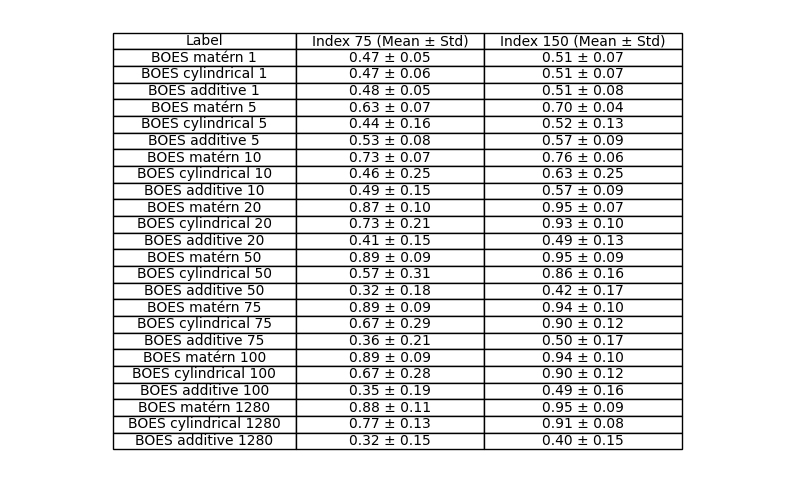

In [36]:
from matplotlib.backends.backend_pdf import PdfPages

# Create a PDF file
with PdfPages('table_output.pdf') as pdf:
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('tight')
    ax.axis('off')

    # Render the table
    table = ax.table(cellText=table_df.values, colLabels=table_df.columns, loc='center', cellLoc='center')

    # Adjust table font size
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(len(table_df.columns))))

    # Save the figure to the PDF
    pdf.savefig(fig)

print("Table saved as 'table_output.pdf'")